In [1]:
# toy abm model from scratch bc why make things easy when they can be hard


In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
test = np.zeros((4,2))
test[0][1] =1 
test[1][1] = 0
test

array([[0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [7]:
i_satisfied(test, 0,0,0,0.5)


True

In [2]:
# first attempt: add agents one by one into a 2d grid and only add to places where they will be satisfied

481 2500


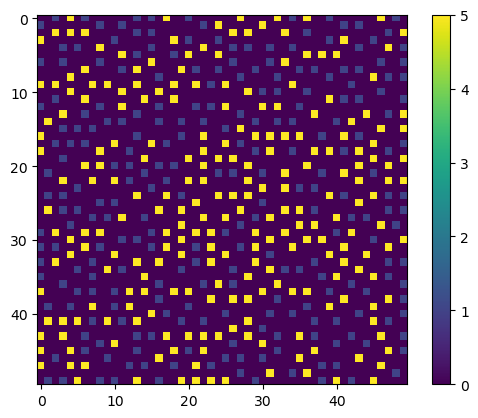

In [6]:
def i_satisfied(board, x, y, color, threshold):
    # check if location is open 
    if board[x][y] != 0:
        return False
    
    # check if i is satisfied with that location: check surrounding pieces (mimicking the segregation model)
    num_good_neighbors = 0
    num_bad_neighbors = 0
    
    for j in range(max(x-1,0), min(x+1+1,len(board[0]))):
        for k in range(max(y-1,0), min(y+1+1,len(board[1]))):
            
            if j == x and k == y:
                continue # skip current location
                
            if board[j][k] == color: 
                num_good_neighbors += 1
                
            elif board[j][k] != 0:
                num_bad_neighbors += 1
                
    if num_good_neighbors == 0 and (num_bad_neighbors == 0):
        return True # empty slot
    
    ratio = num_good_neighbors/(num_bad_neighbors+num_good_neighbors)
    result = ratio >= threshold
    return result
            
i = 0
length = 50
width = 50
board = np.zeros((length,width))
threshold = 0.5

rng = np.random.default_rng() # np.random.randint is not recommended for "new code"

num_successes = 0
num_iter = length*width

for i in range(1,num_iter):
    # set color of i
    if i % 2 == 0:
        color = '1'
    else:
        color = '5'
        
    # until i finds an open satisfactory spot or gets tired, loop
    tries = 5
    while tries >= 0:
        # i chooses its location
        x = rng.integers(0, high=width)
        y = rng.integers(0, high=length)
        
        if i_satisfied(board, x, y, color, threshold): 
            board[x][y] = color
            num_successes += 1
            break
        tries -= 1

print(num_successes, num_iter)
plt.figure()
plt.imshow(board)
plt.colorbar()
plt.show()

In [9]:
test = np.zeros((4,4))

In [10]:
test[0,1] = 1
test

array([[0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [11]:
i_satisfied(test, 0,0,0,0.5)

True

In [12]:
# second try at remaking: following actual model
# initialize agents in a grid and swap around until all agents are satisfied

2326 2500


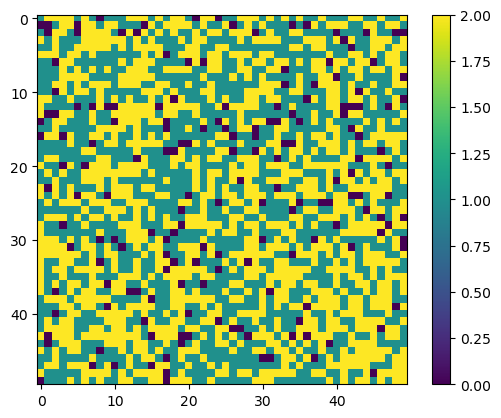

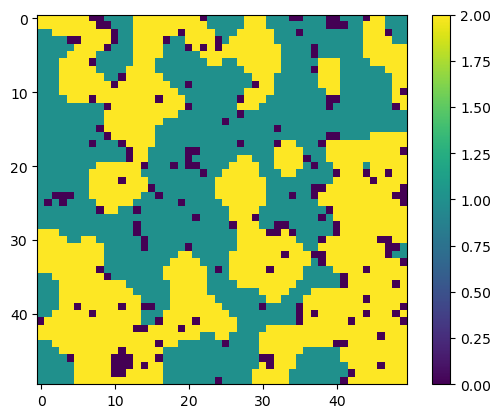

In [14]:
class Agent():
    def __init__(self, color):
        self.color = color
        self.satisfied = False
        self.in_valid_spot = True
        self.x = None
        self.y = None
    def update_position(self, x, y):
        self.x = x
        self.y = y
        

def agent_satisfied(board, x, y, color, threshold):
    
    # check if agent is satisfied with that location: check surrounding pieces (mimicking the segregation model)
    num_good_neighbors = 0
    num_bad_neighbors = 0
    
    for j in range(max(x-1,0), min(x+1+1,len(board[0]))):
        for k in range(max(y-1,0), min(y+1+1,len(board[1]))):
            
            if j == x and k == y:
                continue # skip current location
                
            if board[j][k] == color: 
                num_good_neighbors += 1
                
            elif board[j][k] != 0:
                num_bad_neighbors += 1
                
    if num_good_neighbors == 0 and num_bad_neighbors == 0:
        return True # empty slot
    
    ratio = num_good_neighbors/(num_bad_neighbors+num_good_neighbors)
    result = ratio >= threshold
    return result

def move_agents(board, placed_agents, threshold):
    
    for ag in placed_agents:

        # check agent satisfaction and update
        ag.satisfied = agent_satisfied(board, ag.x, ag.y, ag.color, threshold)

        if ag.satisfied:
            continue

        # not satisfied so move to a random *empty* location
        tries = 10
        width = len(board[0])
        length = len(board[1])
        while tries > 0:

            # i chooses its location
            x = rng.integers(0, high=width)
            y = rng.integers(0, high=length)

            if board[x][y] == 0: 
                board[x][y] = ag.color
                board[ag.x][ag.y] = 0
                ag.update_position(x,y)
                break

            tries -= 1
    return board, placed_agents


# fill board with random populations
i = 0
length = 50
width = 50
board = np.zeros((length,width))
threshold = 0.5

rng = np.random.default_rng() # np.random.randint is not recommended for "new code"

num_successes = 0
num_iter = length*width

# make a bunch of agents: change modulus to make more classes (%2 is binary, %3 is trinary etc)
agents = [Agent(i%2 + 1) for i in range(num_iter)]

placed_agents = []

for ag in agents:
        
    # until i finds an open satisfactory spot or gets tired, loop
    tries = 10
    while tries > 0:
        
        # i chooses its location
        x = rng.integers(0, high=width)
        y = rng.integers(0, high=length)
        
        if board[x][y] == 0: 
            board[x][y] = ag.color
            ag.update_position(x,y)
            num_successes += 1
            placed_agents.append(ag)
            break
            
        tries -= 1
        


print(num_successes, num_iter)
plt.figure()
plt.imshow(board)
plt.colorbar()
plt.show()


            
num_unsatisfied_agents = len(placed_agents)
iter_count = 0
unsatisfaction_log = []
while num_unsatisfied_agents > 5:
    # move agents around if unsatisfied
    move_agents(board, placed_agents, threshold) 
    
    num_unsatisfied_agents = 0
    # after moving, evaluate satisfaction
    for ag in placed_agents:
        ag.satisfied = agent_satisfied(board, ag.x, ag.y, ag.color, threshold)
        if not ag.satisfied:
            num_unsatisfied_agents += 1
    unsatisfaction_log.append(num_unsatisfied_agents / len(placed_agents))
    iter_count += 1
    if iter_count%100 == 0:
        print("iteration: ", iter_count, " num unsatisfied: ", num_unsatisfied_agents / len(placed_agents))
    if (unsatisfaction_log[0] - unsatisfaction_log[-1]) <= 0.03 and iter_count > 1000:
        print("no meaningful change in 1000 iterations, aborting")
        break
    #print("moving")
    
    
plt.figure()
plt.imshow(board)
plt.colorbar()
plt.show()

In [92]:
drinking_preferences = {0: "non", 1: "light_moderate", 2: "heavy"}
drinking_location_preferences = {0: "onsite", 1:"offsite", 2: "both"}

class AlcoholAgent:
    def __init__(self):
        self.x = None
        self.y = None
        
        self.rng = np.random.default_rng()
    
        self.drinking_pref_prob = self.rng.integers(0, high=2)
        self.drinking_preference = drinking_preferences[self.drinking_pref_prob]
        
        if self.drinking_preference == "heavy":
            self.drinking_location_preference = drinking_location_preferences[2]
        elif self.drinking_preference == "non":
            self.drinking_location_preference = drinking_location_preferences[0]
        else:
            self.drinking_location_preference = drinking_location_preferences[self.rng.integers(0, high=1)]
        self.preferred_onsite_outlet_location = (None, None)
        self.preferred_offsite_outlet_location = (None, None)
        
    def update_drinking_preference(self, prob):
        if self.drinking_pref_prob > prob:
            return self.increase_drinking_preference(prob)
        if self.drinking_pref_prob < prob:
            self.decrease_drinking_preference(prob)
        
        
    def increase_drinking_preference(self, prob):    
        if self.drinking_preference = "non":
            self.drinking_preference = "light_moderate"
            return False
        if self.drinking_preference = "light_moderate":
            self.drinking_preference = "heavy"
            return True # returns true if transitioned to heavy
            
    def decrease_drinking_preference(self, prob):
        if self.drinking_preference = "heavy":
            self.drinking_preference = "light_moderate"
        if self.drinking_preference = "light_moderate":
            self.drinking_preference = "non"
    
    
    def update_position(self, x, y):
        self.x = x
        self.y = y
        
class BoardTile:
    def __init__(self, x, y, boardwidth):
        self.x = x
        self.y = y
        self.id = BoardTile.get_id(x,y,boardwidth)
        
        self.contains_agent = False
        
        self.contains_on_premise_outlet = False
        self.contains_off_premise_outlet = False
        self.police_present = False
        
    def __repr__(self):
        return "BoardTile at (" + str(x) + " " + str(y) + ")"
    
    def get_id(x,y,width):
        return y * width + x


SyntaxError: cannot assign to attribute here. Maybe you meant '==' instead of '='? (773103253.py, line 31)

In [93]:
# create board
i = 0
height = 50
width = 50
board = []
threshold = 0.5

rng = np.random.default_rng() 

num_successes = 0
num_iter = length*width

tiles = {}

# initialize board with Tiles class
for i in range(width):
    row = []
    for j in range(height):
        tile = BoardTile(i,j,width)
        row.append(tile)
        tiles[BoardTile.get_id(i,j,width)] = tile
    board.append(row)
    
    
# add random things to board
num_on_premise = 200
num_off_premise = 200
num_police = 10

off_premise_locations = []
off_premise_locations = []

for i in range(num_on_premise):
    tries = 3
    while tries > 0:
        x = rng.integers(0, high=width-1)
        y = rng.integers(0, high=height-1)
        if board[x][y].contains_on_premise_outlet == False and board[x][y].contains_off_premise_outlet == False:
            board[x][y].contains_on_premise_outlet = True
            break
        tries -= 1

            
for i in range(num_off_premise):
    tries = 3
    while tries > 0:
        x = rng.integers(0, high=width-1)
        y = rng.integers(0, high=height-1)
        if board[x][y].contains_on_premise_outlet == False and board[x][y].contains_off_premise_outlet == False:
            board[x][y].contains_off_premise_outlet = True
            break         
        tries -= 1
        
           
for i in range(num_off_premise):
    tries = 3
    while tries > 0:
        x = rng.integers(0, high=width)
        y = rng.integers(0, high=height)
        if board[x][y].police_present == False:
            board[x][y].police_present = True
            break         
        tries -= 1



# make agents
agents = [AlcoholAgent() for i in range(num_iter)]

# place agents


for agent in agents:
    tries = 20
    while tries > 0:
        x = rng.integers(0, high=width)
        y = rng.integers(0, high=height)
        if board[x][y].contains_agent == False:
            board[x][y].contains_agent = True
            agent.update_position(x,y)
            break         
        tries -= 1


# select preferred onsite alcohol outlet in radius -> if there isn't one in radius... i guess just don't have one?
# for simplicity the radius is a square
rad = 10
for site in ["onsite", "offsite"]:
    for agent in agents:

        tries = 10
        pref = agent.drinking_location_preference
        if pref != site and pref != "both":
            continue
            
        if agent.x == None or agent.y == None: # agent wasn't placed
            continue

        while tries > 0:
            x = rng.integers(max(0, agent.x-rad), high = min(agent.x+rad, width-1))
            y = rng.integers(max(0, agent.y-rad), high = min(agent.y+rad, width-1))

        
            tile_id = BoardTile.get_id(x,y,width)
            if site == "onsite":
                if tiles[tile_id].contains_on_premise_outlet:
                    agent.preferred_onsite_outlet_location = (x,y)
                    break
            elif site == "offsite":
                if tiles[tile_id].contains_off_premise_outlet:
                    agent.preferred_offsite_outlet_location = (x,y)
                    break
            tries -= 1




In [94]:
for agent in agents:
    print(agent.preferred_onsite_outlet_location)

(15, 34)
(None, None)
(16, 35)
(35, 20)
(None, None)
(11, 31)
(23, 21)
(None, None)
(None, None)
(16, 43)
(None, None)
(48, 33)
(16, 17)
(None, None)
(None, None)
(4, 11)
(None, None)
(16, 15)
(None, None)
(None, None)
(17, 38)
(None, None)
(None, None)
(0, 27)
(16, 17)
(37, 4)
(48, 28)
(None, None)
(25, 10)
(None, None)
(None, None)
(14, 5)
(42, 24)
(None, None)
(None, None)
(None, None)
(0, 27)
(7, 46)
(0, 7)
(None, None)
(24, 46)
(1, 38)
(11, 37)
(None, None)
(8, 16)
(None, None)
(39, 20)
(None, None)
(40, 23)
(46, 12)
(3, 26)
(16, 35)
(26, 29)
(0, 8)
(42, 41)
(None, None)
(None, None)
(46, 12)
(35, 1)
(25, 10)
(42, 41)
(4, 11)
(None, None)
(None, None)
(None, None)
(20, 22)
(None, None)
(40, 23)
(None, None)
(30, 10)
(None, None)
(36, 27)
(None, None)
(None, None)
(17, 43)
(24, 37)
(7, 31)
(None, None)
(12, 41)
(None, None)
(35, 37)
(None, None)
(48, 9)
(13, 33)
(None, None)
(14, 0)
(46, 17)
(None, None)
(11, 31)
(None, None)
(23, 13)
(46, 38)
(None, None)
(None, None)
(11, 4)
(25,

In [ ]:
rounds = 100
updated_agents = []
for i in range(rounds):
    
    
    for agent in agents: # update drinking preference
        prob = rng.integers(0, high=2)
        if agent.update_drinking_preference(prob) == True:
            
            tries = 10
            pref = agent.drinking_location_preference
            if pref != site and pref != "both":
                continue

            if agent.x == None or agent.y == None: # agent wasn't placed
                continue

            while tries > 0:
                x = rng.integers(max(0, agent.x-rad), high = min(agent.x+rad, width-1))
                y = rng.integers(max(0, agent.y-rad), high = min(agent.y+rad, width-1))


                tile_id = BoardTile.get_id(x,y,width)
                if site == "onsite":
                    if tiles[tile_id].contains_on_premise_outlet:
                        agent.preferred_onsite_outlet_location = (x,y)
                        break
                elif site == "offsite":
                    if tiles[tile_id].contains_off_premise_outlet:
                        agent.preferred_offsite_outlet_location = (x,y)
                        break
                tries -= 1



            
        
    
    rad = 10
    for site in ["onsite", "offsite"]:
        for agent in agents:

            tries = 10
            pref = agent.drinking_location_preference
            if pref != site and pref != "both":
                continue

            if agent.x == None or agent.y == None: # agent wasn't placed
                continue

            while tries > 0:
                x = rng.integers(max(0, agent.x-rad), high = min(agent.x+rad, width-1))
                y = rng.integers(max(0, agent.y-rad), high = min(agent.y+rad, width-1))


                tile_id = BoardTile.get_id(x,y,width)
                if site == "onsite":
                    if tiles[tile_id].contains_on_premise_outlet:
                        agent.preferred_onsite_outlet_location = (x,y)
                        break
                elif site == "offsite":
                    if tiles[tile_id].contains_off_premise_outlet:
                        agent.preferred_offsite_outlet_location = (x,y)
                        break
                tries -= 1


